# 04-1 线性回归：从最小二乘到梯度下降（代码 + 公式讲解）

> 这门课后面的一切（逻辑回归、Softmax、神经网络、深度学习）都建立在本讲之上，所以这里把每一步都拆开讲清楚。

**本讲要回答三个问题：**
1. 线性模型长什么样，参数 $(w,b)$ 为什么必须"从数据里学"？
2. 怎么学？—— 两条路线：**闭合解**（一次算出来）与**梯度下降**（一步步走）。
3. 学出来的模型什么时候会"学坏"（过拟合）？—— **正则化 / 岭回归**。

**使用方式**：从头往下读，每个代码块都可以直接运行；建议自己改改参数（比如学习率、多项式阶数、正则化系数）再跑一遍，感受会更直观。

## 1 线性模型：先从一个例子说起

小明这学期的成绩：期中 80、平时 90、期末 85。很多学校的总评就是"加权求和"：

$$\text{总成绩} = 0.3\times\text{期中} + 0.2\times\text{平时} + 0.5\times\text{期末}$$

把它写成一般形式，就是**线性模型**：

$$f(\boldsymbol{x}) = \boldsymbol{w}^{\mathrm T}\boldsymbol{x} + b = w_1x_1 + w_2x_2 + \cdots + w_dx_d + b$$

- $\boldsymbol{x} = (x_1,\dots,x_d)$：样本在各属性上的取值（特征）；
- $\boldsymbol{w}$：**权重（weight）**，表示每个特征"有多重要"；
- $b$：**偏置（bias）**，可以理解为"基准值"。

整个模型做的事：**输入特征 $\to$ 加权求和 $\to$ 输出预测**。

In [17]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
np.set_printoptions(precision=4, suppress=True)

# 小明的例子：x = (期中, 平时, 期末)
x = np.array([80, 90, 85])
w = np.array([0.3, 0.2, 0.5])   # 权重
b = 0.0                         # 偏置
print("总成绩 =", w @ x + b)

总成绩 = 84.5


### 关键问题：$(w, b)$ 从哪来？

看课件的"房价"故事。A 市的历史成交记录显示：面积越大价格越高，大致满足线性关系，于是有人凭经验拍出

$$\hat y = 2x + 20$$

在 A 市拟合得很好。但如果直接把这条线搬到 B 市（真实规律是 $\hat y = 3x + 60$）呢？

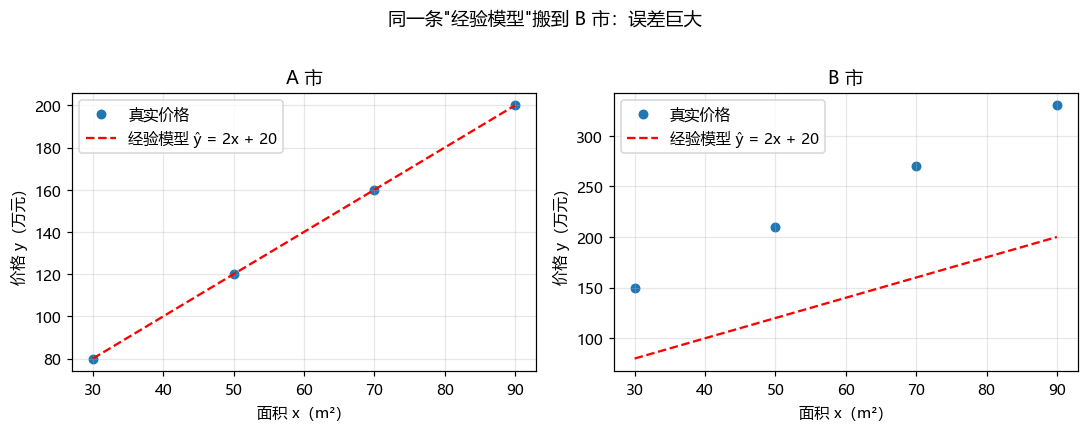

In [18]:
# A 市、B 市的数据（x：面积，y：真实价格）
x = np.array([30., 50., 70., 90.])
y_A = np.array([80., 120., 160., 200.])    # A 市：符合 y = 2x + 20
y_B = np.array([150., 210., 270., 330.])   # B 市：真实规律其实是 y = 3x + 60

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), dpi=110)
for ax, y, city in zip(axes, [y_A, y_B], ['A 市', 'B 市']):
    ax.scatter(x, y, s=30, label='真实价格')
    ax.plot(x, 2*x + 20, 'r--', label='经验模型 ŷ = 2x + 20')
    ax.set_xlabel('面积 x（m²）'); ax.set_ylabel('价格 y（万元）')
    ax.set_title(city); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('同一条"经验模型"搬到 B 市：误差巨大', y=1.02)
plt.tight_layout(); plt.show()

两个图对比可以看出来：**人工指定的 $w, b$ 只适用于特定数据分布，无法适应新的数据规律**。

所以 $(w,b)$ 不应该由人拍脑袋决定，而应该**从数据中自动学习得到** —— 这就把问题变成了一个**优化问题**：

> 找到 $(w, b)$，让预测值 $\hat y$ 与真实值 $y$ 的**总体误差最小**。

## 2 一元线性回归与最小二乘法

先看最简单的情况（一个特征）：模型 $\hat y = wx + b$。

**误差怎么定义？** 单个样本的误差 $e_n = y_n - \hat y_n$ **可正可负**：比如两个样本误差分别是 $+3$ 和 $-3$，直接相加得到 0，仿佛"没误差"，这显然不对。

所以有两个自然的修正：
1. 取绝对值或**平方**（把负号消掉）；
2. 平方还有一个好处：**放大较大的误差**，逼着模型优先处理"错得离谱"的样本。

于是定义**误差平方和（RSS, Residual Sum of Squares）**：

$$\mathrm{RSS}(w,b) = \sum_{n=1}^{N}\bigl(y_n - wx_n - b\bigr)^2$$

**最小二乘法（Least Square Method）** 就是让 RSS 最小：

$$(w^*, b^*) = \arg\min_{w,\,b}\ \sum_{n=1}^{N}(y_n - wx_n - b)^2$$

对一元情形，可以直接给出**闭合解**（推导见第 4 节多元版本，令特征只有 1 个即可）：

$$\hat w = \frac{\sum_n (x_n-\bar x)(y_n-\bar y)}{\sum_n (x_n-\bar x)^2},\qquad \hat b = \bar y - \hat w\,\bar x$$

先看效果：

学到的参数: w = 2.572, b = 0.664   （真实值: w = 2.5, b = 1.0）


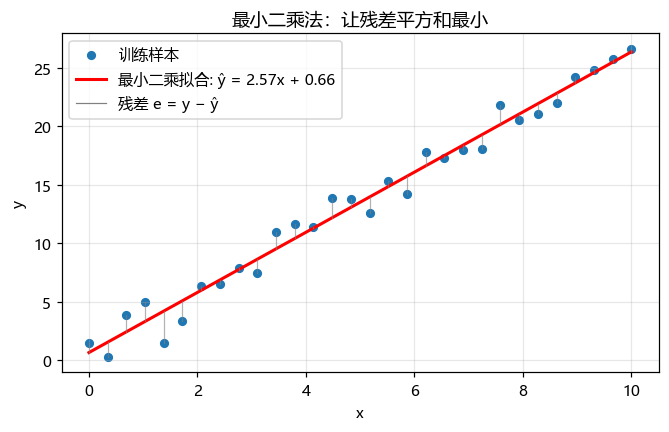

In [19]:
# 造一批"面积-价格"数据：真实规律 y = 2.5x + 1，然后加噪声
rng = np.random.default_rng(42)
x = np.linspace(0, 10, 30)
y = 2.5 * x + 1.0 + rng.normal(0, 1.5, size=x.size)

# 一元最小二乘的闭合解
x_bar, y_bar = x.mean(), y.mean()
w_hat = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
b_hat = y_bar - w_hat * x_bar
print(f'学到的参数: w = {w_hat:.3f}, b = {b_hat:.3f}   （真实值: w = 2.5, b = 1.0）')

plt.figure(figsize=(7, 4), dpi=110)
plt.scatter(x, y, s=25, label='训练样本')
plt.plot(x, w_hat * x + b_hat, 'r-', lw=2, label=f'最小二乘拟合: ŷ = {w_hat:.2f}x + {b_hat:.2f}')
for xi, yi in zip(x, y):
    plt.plot([xi, xi], [yi, w_hat*xi + b_hat], color='gray', lw=0.8, alpha=0.6)
plt.plot([], [], color='gray', lw=0.8, label='残差 e = y − ŷ')
plt.xlabel('x'); plt.ylabel('y'); plt.title('最小二乘法：让残差平方和最小')
plt.legend(); plt.grid(alpha=0.3); plt.show()

### 为什么一定有"唯一的"最优解？

把 $\mathrm{RSS}(w,b)$ 看成 $(w,b)$ 的函数并画出来，它是一个**碗状（凸）曲面**：

- 凸函数只有一个"谷底"，**唯一全局最优**，不存在"停在半山腰"的局部最优问题；
- "贴近数据"由此不再是主观判断，而是由损失函数明确定义。

图上标红星的最高点（谷底）就是最小二乘解：

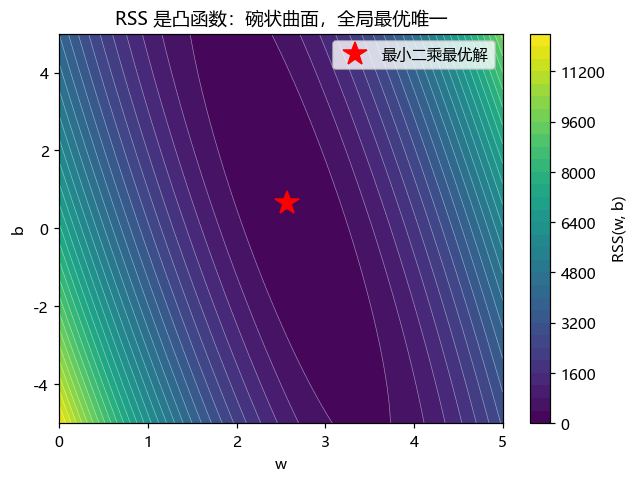

In [20]:
ws = np.linspace(0, 5, 200)
bs = np.linspace(-5, 5, 200)
W, B = np.meshgrid(ws, bs)

# 向量化计算网格上每一点的 RSS
R = ((y[None, None, :] - (W[..., None] * x[None, None, :] + B[..., None])) ** 2).sum(axis=-1)

plt.figure(figsize=(6.5, 4.6), dpi=110)
cs = plt.contourf(W, B, R, levels=30, cmap='viridis')
plt.colorbar(cs, label='RSS(w, b)')
plt.contour(W, B, R, levels=30, colors='white', linewidths=0.4, alpha=0.5)
plt.plot(w_hat, b_hat, 'r*', ms=16, label='最小二乘最优解')
plt.xlabel('w'); plt.ylabel('b'); plt.title('RSS 是凸函数：碗状曲面，全局最优唯一')
plt.legend(); plt.show()

## 3 多元线性回归与矩阵形式

只用一个特征往往不够（面积之外还有距地铁距离、房龄……），模型自然扩展为：

$$\hat y = w_1x_1 + w_2x_2 + \cdots + w_dx_d + b$$

把所有样本摞在一起写成矩阵，就是**多元线性回归**的一般形式：

$$\boldsymbol{y} \approx \boldsymbol{X}\boldsymbol{w}$$

其中 $\boldsymbol{X}$ 是 $N\times(D{+}1)$ 的**设计矩阵**：一行一个样本、一列一个特征，**最后再加一列全是 1 的列**——它和 $b$ 相乘，正好把偏置"吸收"进矩阵乘法里，后面推导就统一了。

**多元最小二乘法**：

$$\boldsymbol{w}^* = \arg\min_{\boldsymbol w}\ \lVert \boldsymbol y - \boldsymbol X\boldsymbol w\rVert_2^2$$

### 闭合解（解析解）推导

记 $J(\boldsymbol w)=\lVert \boldsymbol y-\boldsymbol X\boldsymbol w\rVert_2^2 = (\boldsymbol y-\boldsymbol X\boldsymbol w)^{\mathrm T}(\boldsymbol y-\boldsymbol X\boldsymbol w)$，对 $\boldsymbol w$ 求梯度（用到 $\nabla_{\boldsymbol w}\boldsymbol w^{\mathrm T}\boldsymbol A\boldsymbol w = 2\boldsymbol A\boldsymbol w$）：

$$\nabla J(\boldsymbol w) = 2\boldsymbol X^{\mathrm T}(\boldsymbol X\boldsymbol w-\boldsymbol y)$$

凸函数的极值点处**梯度为零**，于是：

$$2\boldsymbol X^{\mathrm T}(\boldsymbol X\boldsymbol w-\boldsymbol y)=0 \;\Longrightarrow\; \underbrace{\boldsymbol X^{\mathrm T}\boldsymbol X}_{\text{正规方程}}\boldsymbol w = \boldsymbol X^{\mathrm T}\boldsymbol y \;\Longrightarrow\; \boxed{\ \boldsymbol w^{*} = (\boldsymbol X^{\mathrm T}\boldsymbol X)^{-1}\boldsymbol X^{\mathrm T}\boldsymbol y\ }$$

它的优点是**一次就把最优参数算出来**（后面第 5 节会讲它的缺点）。

In [21]:
# 造多元数据：价格 ≈ 2.0 * 面积 − 15 * 距地铁距离 + 40
rng = np.random.default_rng(0)
N = 50
area = rng.uniform(30, 120, N)      # 面积
dist = rng.uniform(0.2, 3.0, N)     # 距地铁距离
price = 2.0*area - 15*dist + 40 + rng.normal(0, 8, N)

X = np.column_stack([area, dist, np.ones(N)])   # 设计矩阵：两列特征 + 一列 1（吸收偏置）
y = price

# 闭合解 w* = (XᵀX)^(-1) Xᵀy —— 求逆不如直接解方程，数值上更稳
w_closed = np.linalg.solve(X.T @ X, X.T @ y)
w_lstsq, *_ = np.linalg.lstsq(X, y, rcond=None)

print('闭合解  w =', np.round(w_closed, 3))
print('lstsq   w =', np.round(w_lstsq, 3))
print('真实参数：w = [2.0, -15.0, 40.0]（第三个数是偏置 b）')

闭合解  w = [  1.956 -16.034  45.013]
lstsq   w = [  1.956 -16.034  45.013]
真实参数：w = [2.0, -15.0, 40.0]（第三个数是偏置 b）


In [22]:
# 验证"梯度为零"：在最优点处计算 ∇J，应该几乎是 0
grad_at_opt = 2 * X.T @ (X @ w_closed - y)
print('∇J(w*) =', np.round(grad_at_opt, 10))

∇J(w*) = [-0.  0.  0.]


> **小坑**：当特征之间高度相关（多重共线性）时，$\boldsymbol X^{\mathrm T}\boldsymbol X$ 会接近不可逆，闭合解会变得不稳定甚至没有唯一解——这正是后面**岭回归**要解决的问题（第 9 节）。

## 4 梯度下降：换一条路求最优

闭合解虽好，但有两个实际问题：

1. 它要显式地算 $\boldsymbol X^{\mathrm T}\boldsymbol X$（$D\times D$ 矩阵）并求解线性方程组，当**样本多、特征多**时计算和内存代价都很大；
2. 很多模型（比如后面的逻辑回归、神经网络）**根本没有闭合解**，只能迭代求解。

所以需要第二条路线 —— **梯度下降法（Gradient Descent）**：不直接求公式，而是**沿着下降方向一步一步走**：

$$\boldsymbol w \leftarrow \boldsymbol w - \eta\,\frac{\partial J}{\partial \boldsymbol w}, \qquad \frac{\partial J}{\partial \boldsymbol w} = 2\boldsymbol X^{\mathrm T}(\boldsymbol X\boldsymbol w - \boldsymbol y)$$

其中 $\eta$ 是**学习率**（十分重要的超参数）：
- $\eta$ 太小 → 走得慢，收敛要很多步；
- $\eta$ 太大 → 步子迈过头，损失震荡甚至发散；
- 合适的 $\eta$ → 稳步下降。

> **动手前的重要一步**：先统一特征尺度（标准化）。如果两个特征一个是"面积（几十~几百）"、一个是"距离（零点几~几）"，梯度会被大尺度的特征主导，收敛非常慢。这也是 KNN 那讲"分类前先标准化"的同一个道理。

梯度下降解（标准化尺度下）: [ 51.3013 -14.0454 167.633 ]
闭合解    （标准化尺度下）: [ 51.3013 -14.0454 167.633 ]
两解最大差距: 1.42e-14
换算回原始尺度: [  1.956 -16.034  45.013]  ← 与第 3 节闭合解一致


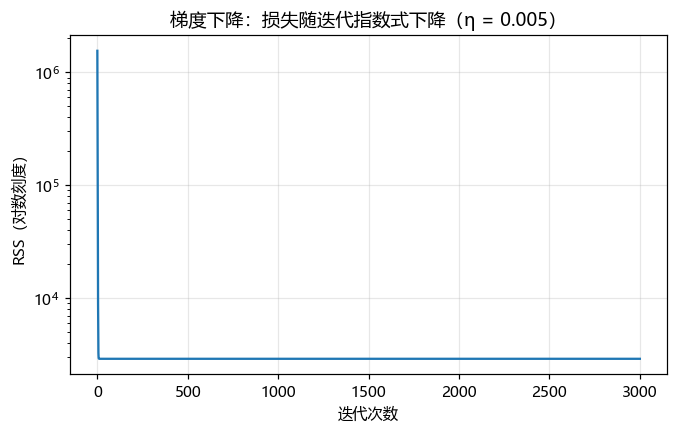

In [23]:
# 特征标准化（注意：这一步会改变参数的含义，预测时要按同样的变换处理新数据）
Xf = X[:, :2]
mu, sigma = Xf.mean(axis=0), Xf.std(axis=0)
Xs = np.column_stack([(Xf - mu) / sigma, np.ones(N)])

def loss(w):
    return float(((y - Xs @ w) ** 2).sum())

w = np.zeros(3)
eta = 0.005
history = [loss(w)]
for t in range(3000):
    g = 2 * Xs.T @ (Xs @ w - y)      # ∇J(w) = 2Xᵀ(Xw − y)
    w = w - eta * g
    history.append(loss(w))

w_opt = np.linalg.solve(Xs.T @ Xs, Xs.T @ y)   # 闭合解作对照
print('梯度下降解（标准化尺度下）:', np.round(w, 4))
print('闭合解    （标准化尺度下）:', np.round(w_opt, 4))
print('两解最大差距:', f'{np.abs(w - w_opt).max():.2e}')

# 把标准化尺度下的参数"换算回"原始尺度，就能和前面第 3 节的结果对上：
# x_s = (x − μ)/σ  ⟹  w_原 = w_标/σ ，b_原 = b_标 − Σ w_标·μ/σ
w_raw = w[:2] / sigma
b_raw = w[2] - (w[:2] * mu / sigma).sum()
print('换算回原始尺度:', np.round(np.r_[w_raw, b_raw], 3), ' ← 与第 3 节闭合解一致')

plt.figure(figsize=(7, 4), dpi=110)
plt.plot(history)
plt.yscale('log')
plt.xlabel('迭代次数'); plt.ylabel('RSS（对数刻度）')
plt.title(f'梯度下降：损失随迭代指数式下降（η = {eta}）')
plt.grid(alpha=0.3); plt.show()

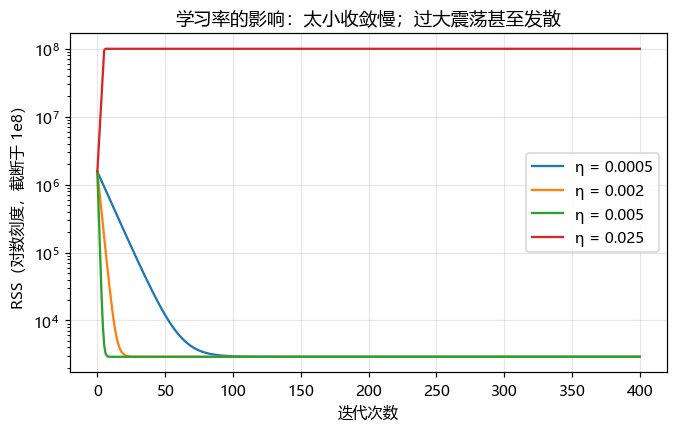

In [24]:
# 学习率的影响：太小走得慢，太大震荡/发散
plt.figure(figsize=(7, 4), dpi=110)
for eta in [0.0005, 0.002, 0.005, 0.025]:
    w = np.zeros(3); h = [loss(w)]
    for t in range(400):
        g = 2 * Xs.T @ (Xs @ w - y)
        w = w - eta * g
        h.append(loss(w))
    plt.plot(np.minimum(h, 1e8), label=f'η = {eta}')
plt.yscale('log')
plt.xlabel('迭代次数'); plt.ylabel('RSS（对数刻度，截断于 1e8）')
plt.title('学习率的影响：太小收敛慢；过大震荡甚至发散')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5 几何解释：最小二乘 = 正交投影

把 $\boldsymbol X$ 的每一列看作一个向量，它们张成一个**子空间**（想象成一张"平面"）。模型所有可能的预测结果 $\boldsymbol X\boldsymbol w$ 都落在这个平面里。

最小二乘要找的是：**平面上离真实向量 $\boldsymbol y$ 最近的那个点**。

几何常识告诉我们：最近点对应的残差 $\boldsymbol y - \boldsymbol X\boldsymbol w^*$ 一定**垂直于**这个平面，即垂直于 $\boldsymbol X$ 的每一列：

$$\boldsymbol X^{\mathrm T}(\boldsymbol y - \boldsymbol X\boldsymbol w^*) = 0 \;\Longleftrightarrow\; \boldsymbol X^{\mathrm T}\boldsymbol X\boldsymbol w^* = \boldsymbol X^{\mathrm T}\boldsymbol y$$

看！这正是前面"令梯度为零"得到的正规方程 —— **代数和几何在这里对上了**。所以最小二乘的几何含义就是：把 $\boldsymbol y$ **正交投影**到 $\boldsymbol X$ 列空间上。

**光说不够直观，直接画出来看。** 为了把图画得最清楚，下面用一个**特制的小例子**（几何结论对一般的 $\boldsymbol X$ 完全一样）：

- 3 个样本，$\boldsymbol X$ 的两列恰好取 $\boldsymbol e_1=(1,0,0)$ 和 $\boldsymbol e_2=(0,1,0)$ —— 这样 $\boldsymbol X$ 的**列空间正好是水平面**（"地板"），垂直关系一眼可见；
- 观测值取 $\boldsymbol y=(2,3,4)$：它在平面上的投影就是正下方的 $(2,3,0)$，残差 $(0,0,4)$ 竖直向上。

图上能直接看到：**预测值（绿）永远落在平面上，残差（黑虚线）与平面成直角** —— 这就是"正交投影"四个字的全部含义。

最小二乘解 w* = [2. 3.]  → 投影点 Xw* = [2. 3. 0.]
残差 y − Xw* = [0. 0. 4.]
Xᵀ(残差) = [0. 0.] （与平面两列的内积都 ≈ 0 → 残差垂直于平面）


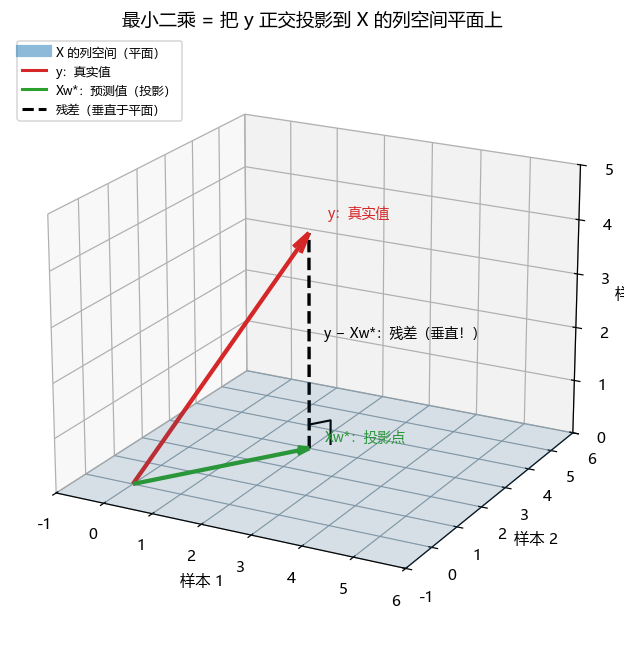

In [25]:
# —— 特制小例子：让列空间正好"平躺"（水平面），把正交投影画成 3D 图 ——
# X 的两列 = e1、e2（只为画图方便；把 X 换成任何矩阵，几何结论都一样）
X_toy = np.array([[1., 0.],
                  [0., 1.],
                  [0., 0.]])
y_toy = np.array([2., 3., 4.])
w_toy, *_ = np.linalg.lstsq(X_toy, y_toy, rcond=None)

y_hat = X_toy @ w_toy          # Xw*：y 在平面上的投影点
resid = y_toy - y_hat          # 残差向量
print('最小二乘解 w* =', np.round(w_toy, 3), ' → 投影点 Xw* =', np.round(y_hat, 3))
print('残差 y − Xw* =', np.round(resid, 3))
print('Xᵀ(残差) =', np.round(X_toy.T @ resid, 12), '（与平面两列的内积都 ≈ 0 → 残差垂直于平面）')

fig = plt.figure(figsize=(9.6, 6.0), dpi=110)
ax = fig.add_subplot(111, projection='3d')

# ① 列空间：水平面（z = 0），铺一层淡淡的网格增强"平面感"
gx, gy = np.meshgrid(np.linspace(-1, 6, 2), np.linspace(-1, 6, 2))
ax.plot_surface(gx, gy, np.zeros_like(gx), color='tab:blue', alpha=0.14, edgecolor='none')
for tt in np.arange(0, 6.1, 1.0):
    ax.plot([tt, tt], [-1, 6], [0, 0], color='tab:blue', lw=0.4, alpha=0.3)
    ax.plot([-1, 6], [tt, tt], [0, 0], color='tab:blue', lw=0.4, alpha=0.3)

# ② 三根关键向量
ax.quiver(0, 0, 0, *y_toy, color='tab:red', lw=2.8, arrow_length_ratio=0.07)      # y：从原点出发
ax.quiver(0, 0, 0, *y_hat, color='tab:green', lw=2.8, arrow_length_ratio=0.07)    # 投影：落在平面里
ax.plot([y_hat[0], y_toy[0]], [y_hat[1], y_toy[1]], [y_hat[2], y_toy[2]],
        color='k', ls='--', lw=2.2)                                               # 残差：竖直向上

# ③ 直角小方块：标出"残差 ⊥ 平面"
u = resid / np.linalg.norm(resid)      # 垂直方向（残差方向）
v = y_hat / np.linalg.norm(y_hat)      # 平面内的方向
s = 0.45
corner = np.array([y_hat + s*u, y_hat + s*u + s*v, y_hat + s*v])
ax.plot(corner[:, 0], corner[:, 1], corner[:, 2], color='k', lw=1.4)

ax.text(*(y_toy + 0.25), 'y：真实值', color='tab:red', fontsize=9)
ax.text(*(y_hat + np.array([0.2, 0.25, 0.1])), 'Xw*：投影点', color='tab:green', fontsize=9)
ax.text(2.25, 3.1, 2.1, 'y − Xw*：残差（垂直！）', color='k', fontsize=9)

ax.set_xlabel('样本 1'); ax.set_ylabel('样本 2'); ax.set_zlabel('样本 3')
ax.set_xlim(-1, 6); ax.set_ylim(-1, 6); ax.set_zlim(0, 5)
ax.set_box_aspect([1, 1, 0.75])
ax.view_init(elev=20, azim=-62)
ax.set_title('最小二乘 = 把 y 正交投影到 X 的列空间平面上')

from matplotlib.lines import Line2D
handles = [Line2D([], [], color='tab:blue', alpha=0.5, lw=8, label='X 的列空间（平面）'),
           Line2D([], [], color='tab:red', lw=2, label='y：真实值'),
           Line2D([], [], color='tab:green', lw=2, label='Xw*：预测值（投影）'),
           Line2D([], [], color='k', lw=2, ls='--', label='残差（垂直于平面）')]
ax.legend(handles=handles, loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

In [26]:
# 验证：残差与 X 的每一列都垂直（内积 ≈ 0）
residual = y - Xs @ w_opt
print('Xᵀ(y − Xw*) =', np.round(Xs.T @ residual, 10), '  ← 每一项都 ≈ 0，说明残差垂直')
print('残差平方和 ‖y − Xw*‖² =', round(float(residual @ residual), 3))

Xᵀ(y − Xw*) = [ 0. -0.  0.]   ← 每一项都 ≈ 0，说明残差垂直
残差平方和 ‖y − Xw*‖² = 2911.052


## 6 概率解释：最小二乘为什么如此自然？

换一个视角：假设真实规律是 $\boldsymbol y = \boldsymbol X\boldsymbol w + \boldsymbol\epsilon$，噪声 $\boldsymbol\epsilon$ 服从**零均值等方差的高斯分布** $\mathcal N(0,\sigma^2)$ 且各样本独立。写出似然并取对数：

$$\max_{\boldsymbol w}\ p(\boldsymbol y\mid \boldsymbol X,\boldsymbol w)
= \max_{\boldsymbol w}\ \prod_n \frac{1}{\sqrt{2\pi}\sigma}\exp\!\Bigl(-\frac{(y_n-\boldsymbol x_n^{\mathrm T}\boldsymbol w)^2}{2\sigma^2}\Bigr)
\;\Longleftrightarrow\; \min_{\boldsymbol w}\ \sum_n (y_n-\boldsymbol x_n^{\mathrm T}\boldsymbol w)^2$$

**结论**：高斯噪声假设下，**极大似然估计（MLE）等价于最小二乘**。也就是说，最小二乘不是什么"拍脑袋的规则"，它有坚实的概率依据。

再往前一步：
- 若给参数 $\boldsymbol w$ 再加一个**零均值高斯先验**，最大后验估计（MAP）等价于"最小二乘 + L2 正则化"，即**岭回归**；
- 若先验是均匀分布，MAP 退化为 MLE，岭回归又退回最小二乘。

In [27]:
# 小验证：最小二乘解同时也是"负对数似然"最小的解（两者只差常数项）
def neg_log_lik(w, X, y, sigma=1.0):
    e = y - X @ w
    return float(0.5 * (e @ e) / sigma**2 + len(y) * np.log(sigma * np.sqrt(2*np.pi)))

w_nearby = w_opt + np.array([0.1, -0.1, 0.1])   # 随便挪一步的"邻近解"
print('NLL(最小二乘解) =', round(neg_log_lik(w_opt, Xs, y), 3))
print('NLL(邻近另一个解) =', round(neg_log_lik(w_nearby, Xs, y), 3), ' ← 更大')
print('NLL(w = 0)      =', round(neg_log_lik(np.zeros(3), Xs, y), 3), ' ← 更大')

NLL(最小二乘解) = 1501.473
NLL(邻近另一个解) = 1502.243  ← 更大
NLL(w = 0)      = 776212.006  ← 更大


## 7 过拟合：阶数越高 ≠ 越好

模型太简单，学不到规律（**欠拟合**）；模型太复杂，会把噪声也当成规律记住（**过拟合**）。

用一个经典实验体会（课件里那张"系数爆炸"的表就来自它）：真实规律是光滑曲线 $y=\sin(2\pi x)$（$x\in[0,1]$），我们**只采 10 个带噪声的点**，用不同阶数的多项式去拟合（$M$ 越大模型越复杂）：

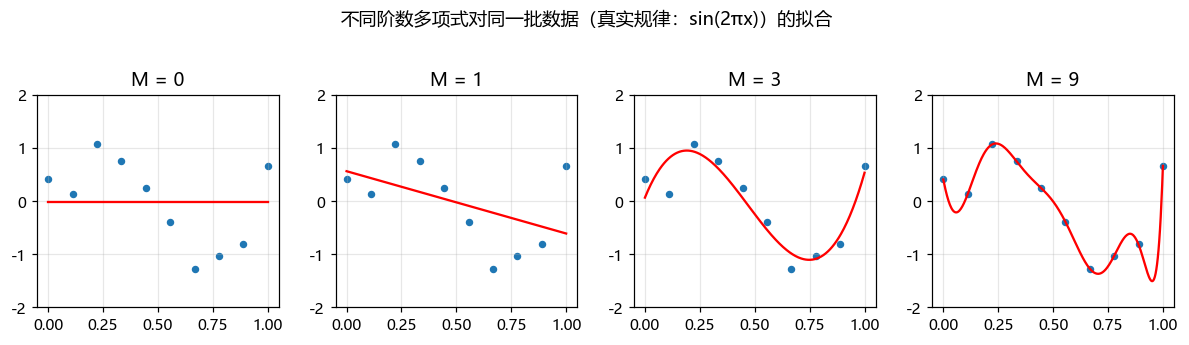

M = 1: max|w| =         1.17
M = 3: max|w| =        33.47
M = 9: max|w| =    166267.21
M = 9 的完整系数解 w* =
[      0.41     -20.62     124.18    1631.69  -17768.05   70417.73
 -145451.58  166267.21  -99618.59   24418.27]


In [28]:
rng = np.random.default_rng(3)
x = np.linspace(0, 1, 10)                      # 只采 10 个点
y = np.sin(2 * np.pi * x) + 0.2 * rng.normal(size=x.size)

def poly_features(x, M):
    # 返回 [1, x, x^2, ..., x^M]，即把 x 变换成多项式特征
    return np.vander(np.asarray(x), M + 1, increasing=True)

xs = np.linspace(0, 1, 300)
plt.figure(figsize=(11, 3), dpi=110)
for i, M in enumerate([0, 1, 3, 9]):
    Phi = poly_features(x, M)
    w = np.linalg.lstsq(Phi, y, rcond=None)[0]
    ax = plt.subplot(1, 4, i + 1)
    ax.scatter(x, y, s=15)
    ax.plot(xs, poly_features(xs, M) @ w, 'r-')
    ax.set_title(f'M = {M}'); ax.set_ylim(-2, 2); ax.grid(alpha=0.3)
plt.suptitle('不同阶数多项式对同一批数据（真实规律：sin(2πx)）的拟合', y=1.03)
plt.tight_layout(); plt.show()

# 看看各阶解的系数大小（对应课件里的"系数爆炸"表）
w9 = None
for M in [1, 3, 9]:
    Phi = poly_features(x, M)
    w = np.linalg.lstsq(Phi, y, rcond=None)[0]
    print(f'M = {M}: max|w| = {np.abs(w).max():>12.2f}')
    if M == 9: w9 = w
print('M = 9 的完整系数解 w* =')
print(np.round(w9, 2))

$M=9$ 时曲线在训练点上完全穿过，但两端疯狂震荡；同时**系数急剧变大**——这正是课件里那张"系数爆炸"表的来源（$M=9$ 时系数可达 $10^5\sim10^6$ 量级）。

系数越大 → 输入稍微变化一点，输出就剧烈变化 → 对没见过的新样本预测极差。**这就是过拟合的信号。**

## 8 正则化与岭回归

对策：给目标函数加一项"约束"，不让参数长得太放肆：

$$\min_{\boldsymbol w}\ \underbrace{\tfrac12\lVert \boldsymbol y-\boldsymbol X\boldsymbol w\rVert_2^2}_{\text{数据项：拟合训练数据}} + \underbrace{\tfrac{\lambda}{2}\lVert \boldsymbol w\rVert_2^2}_{\text{正则项（L2）：限制参数大小}}$$

这项改动带来一个漂亮的副产品 —— **解也变了**（推导同第 3 节，多了一步 $+\lambda\boldsymbol I$）：

$$\boldsymbol w^* = (\boldsymbol X^{\mathrm T}\boldsymbol X + \lambda\boldsymbol I)^{-1}\boldsymbol X^{\mathrm T}\boldsymbol y$$

- $\boldsymbol X^{\mathrm T}\boldsymbol X + \lambda\boldsymbol I$ 一定可逆（$\lambda>0$ 时），顺手解决了前面"矩阵可能不可逆"的坑；
- $\lambda$ 控制正则化强度：**$\lambda=0$ → 退化为普通最小二乘（可能过拟合）；$\lambda$ 适中 → 泛化最好；$\lambda$ 过大 → 参数被压得太狠（欠拟合）**。

同一个 $M=9$ 的多项式拟合，换个 $\lambda$ 试试：

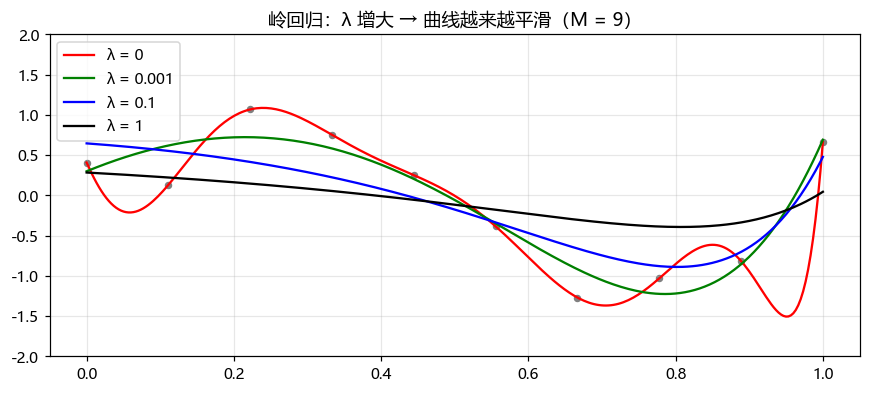

In [29]:
def ridge_fit(Phi, y, lam):
    # 岭回归闭合解 w* = (ΦᵀΦ + λI)^(-1) Φᵀy
    return np.linalg.solve(Phi.T @ Phi + lam * np.eye(Phi.shape[1]), Phi.T @ y)

M = 9
Phi = poly_features(x, M)
Phis = poly_features(xs, M)

plt.figure(figsize=(9.5, 3.8), dpi=110)
for lam, style in zip([0, 1e-3, 1e-1, 1], ['r-', 'g-', 'b-', 'k-']):
    w = ridge_fit(Phi, y, lam)
    plt.plot(xs, Phis @ w, style, label=f'λ = {lam}')
plt.scatter(x, y, s=15, color='gray')
plt.ylim(-2, 2); plt.legend(); plt.grid(alpha=0.3)
plt.title('岭回归：λ 增大 → 曲线越来越平滑（M = 9）')
plt.show()

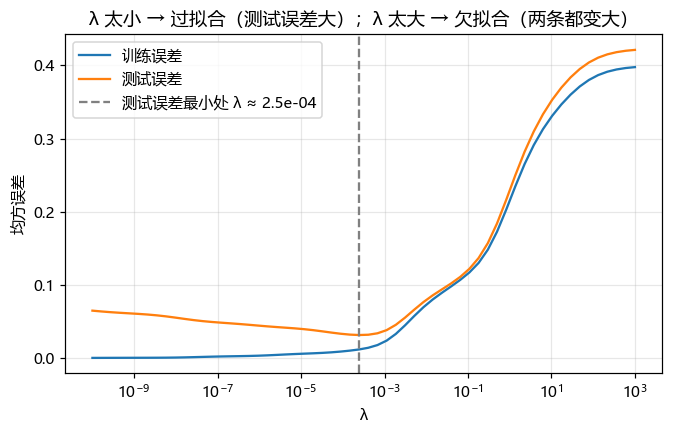

In [30]:
# λ 取多大合适？—— 用"训练误差 / 测试误差"来选
rng = np.random.default_rng(7)
xtr = np.linspace(0, 1, 10); ytr = np.sin(2*np.pi*xtr) + 0.2 * rng.normal(size=10)
xte = np.linspace(0, 1, 50); yte = np.sin(2*np.pi*xte) + 0.2 * rng.normal(size=50)

M = 9
Phi_tr, Phi_te = poly_features(xtr, M), poly_features(xte, M)
lams = np.logspace(-10, 3, 60)
tr_err, te_err = [], []
for lam in lams:
    w = ridge_fit(Phi_tr, ytr, lam)
    tr_err.append(((ytr - Phi_tr @ w) ** 2).mean())
    te_err.append(((yte - Phi_te @ w) ** 2).mean())

best_lam = lams[int(np.argmin(te_err))]
plt.figure(figsize=(7, 4), dpi=110)
plt.semilogx(lams, tr_err, label='训练误差')
plt.semilogx(lams, te_err, label='测试误差')
plt.axvline(best_lam, color='gray', ls='--', label=f'测试误差最小处 λ ≈ {best_lam:.1e}')
plt.xlabel('λ'); plt.ylabel('均方误差'); plt.legend(); plt.grid(alpha=0.3)
plt.title('λ 太小 → 过拟合（测试误差大）；λ 太大 → 欠拟合（两条都变大）')
plt.show()

> **L1 与 L2 的分工**（了解）：L2（岭回归）让解更平滑、稳定；L1（Lasso）$\min \frac12\lVert y-Ax\rVert_2^2+\lambda\lVert x\rVert_1$ 会**鼓励稀疏**（很多参数被压成 0），可用于"选择重要特征"。它们的概率解释分别是"高斯先验"和"拉普拉斯先验"。

## 9 小结与自测

**一张图记住本讲逻辑链：**

| 步骤 | 内容 |
|---|---|
| 模型 | $f(\boldsymbol x)=\boldsymbol w^{\mathrm T}\boldsymbol x+b$，参数从数据学 |
| 目标 | 最小化 RSS $=\sum_n(y_n-\hat y_n)^2$（凸函数 → 唯一最优） |
| 求解 ① | 闭合解 $\boldsymbol w^*=(\boldsymbol X^{\mathrm T}\boldsymbol X)^{-1}\boldsymbol X^{\mathrm T}\boldsymbol y$ |
| 求解 ② | 梯度下降 $\boldsymbol w \leftarrow \boldsymbol w-\eta\nabla J$，$\nabla J = 2\boldsymbol X^{\mathrm T}(\boldsymbol X\boldsymbol w-\boldsymbol y)$ |
| 几何 | 最小二乘 = $\boldsymbol y$ 到 $\boldsymbol X$ 列空间的正交投影 |
| 概率 | 高斯噪声下 MLE ⟺ 最小二乘；高斯先验下 MAP ⟺ 岭回归 |
| 防过拟合 | 正则化 $\min D(\boldsymbol x)+\lambda R(\boldsymbol x)$，$\lambda$ 由验证集选 |

**自测题**（想不出就回到对应小节看）：
1. 为什么误差要平方而不是直接相加？（第 2 节：正负抵消）
2. RSS 是凸函数意味着什么？（第 2 节：唯一全局最优）
3. 闭合解和梯度下降各自的适用场景？（第 4 节：规模、是否有闭式解）
4. 为什么梯度下降前要标准化特征？（第 4 节：尺度主导梯度）
5. $\lambda \to 0$ 和 $\lambda \to \infty$ 时岭回归分别变成什么？（第 8 节：最小二乘 / 参数被压没）
6. 线性回归怎么处理非线性关系？（提示：多项式特征是"特征变换"的例子）